## Step-1. Data Loading & Preliminary Inspection

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import pickle

# Set plotting styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11

print("  Libraries imported successfully!")

  Libraries imported successfully!


In [2]:
# Define paths
csv_path = "finance_sales_01(2).csv"
if not os.path.exists(csv_path):
    csv_path =  r'C:\Users\akumalla.jahnavi.EXAFLUENCE-INC\Desktop\testing app project\finance_sales_01.csv'


# Load dataframe
df = pd.read_csv(csv_path)

print(f"Dataset successfully loaded")
print(f" Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Column Names:\n{df.columns.tolist()}")
print(f"\n Data Types:\n{df.dtypes}")
print(f"\n Missing Values:\n{df.isnull().sum().sum()} total null values")
print(f"\n First 5 Rows:")
df.head()

Dataset successfully loaded
 Dimensions: 74,386 rows × 38 columns

 Column Names:
['lead_id', 'lead_source', 'product_category', 'product_sub_category', 'deal_value_usd', 'customer_type', 'customer_age', 'customer_gender', 'customer_employment_type', 'customer_annual_income', 'customer_credit_score', 'customer_state', 'customer_city_tier', 'customer_existing_products_count', 'customer_relationship_tenure_years', 'customer_debt_to_income_ratio', 'sales_rep_id', 'sales_rep_region', 'sales_rep_experience_years', 'sales_rep_tier', 'sales_rep_monthly_quota_usd', 'sales_rep_ytd_quota_attainment_pct', 'first_contact_response_hrs', 'days_in_pipeline', 'last_stage_reached', 'num_total_touchpoints', 'num_calls_made', 'num_emails_sent', 'num_meetings_held', 'proposal_sent', 'needs_analysis_completed', 'competitor_present', 'discount_offered_pct', 'manager_escalated', 'customer_objection_raised', 'follow_up_consistency_score', 'sentiment_last_interaction', 'converted']

 Data Types:
lead_id       

,lead_id,lead_source,product_category,product_sub_category,deal_value_usd,customer_type,customer_age,customer_gender,customer_employment_type,customer_annual_income,...,num_meetings_held,proposal_sent,needs_analysis_completed,competitor_present,discount_offered_pct,manager_escalated,customer_objection_raised,follow_up_consistency_score,sentiment_last_interaction,converted
0,LEAD000001,Referral,Personal Loan,General Purpose,15306,New,54,Female,Salaried,101696,...,3,1,0,1,5.4,0,0,65,Neutral,0
1,LEAD000002,Email Campaign,Investment Account,Retirement (IRA),56715,Existing,61,Female,Self-Employed,192415,...,0,0,1,1,0.0,0,0,89,Neutral,0
2,LEAD000003,Branch Walk-In,Credit Card,Secured,8424,New,42,Female,Self-Employed,112486,...,4,1,1,0,0.8,0,1,60,Neutral,0
3,LEAD000004,Cold Call,Home Loan,Construction,281936,Existing,33,Male,Salaried,49835,...,4,1,0,0,3.6,1,0,70,Neutral,1
4,LEAD000005,Branch Walk-In,Personal Loan,Travel,17129,New,62,Male,Retired,62904,...,2,0,1,0,0.0,0,1,59,Neutral,0


In [3]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,deal_value_usd,customer_age,customer_annual_income,customer_credit_score,customer_existing_products_count,customer_relationship_tenure_years,customer_debt_to_income_ratio,sales_rep_experience_years,sales_rep_monthly_quota_usd,sales_rep_ytd_quota_attainment_pct,...,num_emails_sent,num_meetings_held,proposal_sent,needs_analysis_completed,competitor_present,discount_offered_pct,manager_escalated,customer_objection_raised,follow_up_consistency_score,converted
count,7.438600e+04,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,...,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000,74386.000000
mean,7.815541e+04,43.010876,95526.044968,603.356304,1.424408,2.770650,0.285341,9.259564,124222.384131,87.299404,...,10.774756,2.586562,0.651036,0.478894,0.232893,2.133352,0.141720,0.382048,65.337375,0.353360
std,1.322156e+05,13.063871,58892.349008,55.818344,1.678940,4.418646,0.159516,5.484356,43736.878254,20.066629,...,3.578954,1.441467,0.476646,0.499558,0.422678,3.458724,0.348765,0.485891,13.212703,0.478016
min,5.000000e+02,22.000000,12000.000000,376.000000,0.000000,0.000000,0.020000,1.500000,58547.000000,17.300000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000
25%,7.229250e+03,33.000000,56626.250000,566.000000,0.000000,0.000000,0.160000,4.900000,90247.000000,75.800000,...,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,0.000000
50%,1.926800e+04,43.000000,81831.000000,604.000000,1.000000,0.500000,0.260000,8.200000,113594.000000,87.300000,...,11.000000,3.000000,1.000000,0.000000,0.000000,0.300000,0.000000,0.000000,65.000000,0.000000
75%,7.643400e+04,52.000000,118911.000000,641.000000,3.000000,4.000000,0.390000,12.400000,148544.000000,101.200000,...,14.000000,4.000000,1.000000,1.000000,0.000000,3.000000,0.000000,1.000000,74.000000,1.000000
max,1.580558e+06,78.000000,780567.000000,849.000000,8.000000,30.000000,0.750000,25.000000,250000.000000,151.500000,...,24.000000,10.000000,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,100.000000,1.000000


## Step-2. Exploratory Data Analysis (EDA)

In [4]:
# Check target variable distribution
print("Target Variable Distribution:")
print(df['converted'].value_counts())
print(f"\nConversion Rate: {df['converted'].mean()*100:.2f}%")

Target Variable Distribution:
converted
0    48101
1    26285
Name: count, dtype: int64

Conversion Rate: 35.34%


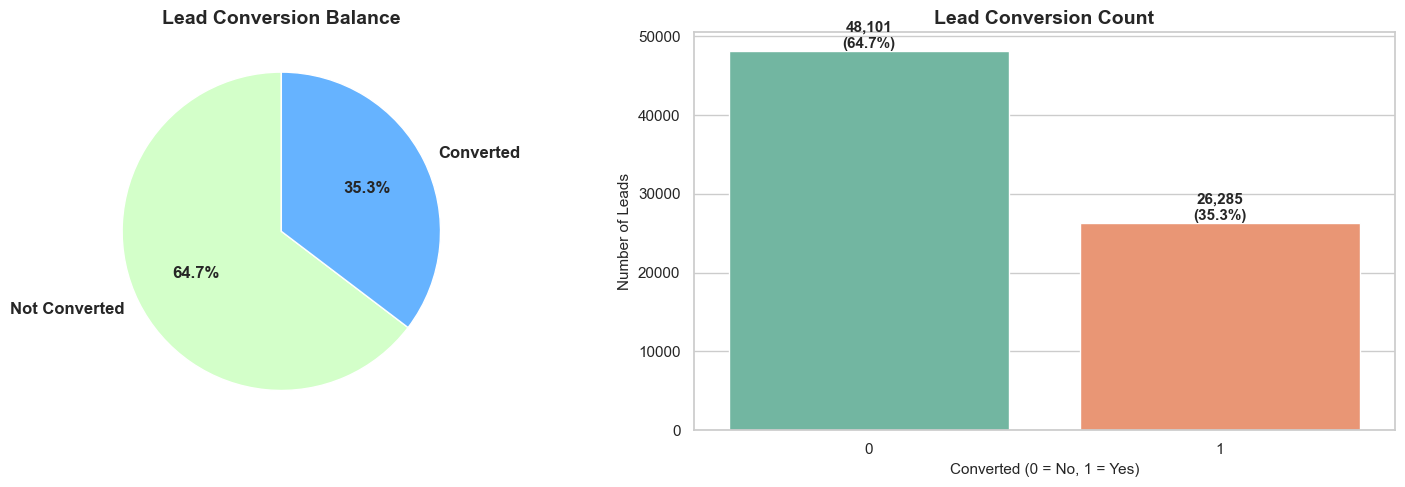

In [5]:
# Class Balance Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart
colors = ["#acff9985", '#66b3ff']
converted_counts = df['converted'].value_counts()
axes[0].pie(converted_counts.values, labels=['Not Converted', 'Converted'], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Lead Conversion Balance', fontsize=14, fontweight='bold')

# Count plot
sns.countplot(x='converted', hue='converted', data=df, palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Lead Conversion Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Converted (0 = No, 1 = Yes)', fontsize=11)
axes[1].set_ylabel('Number of Leads', fontsize=11)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f}%)', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

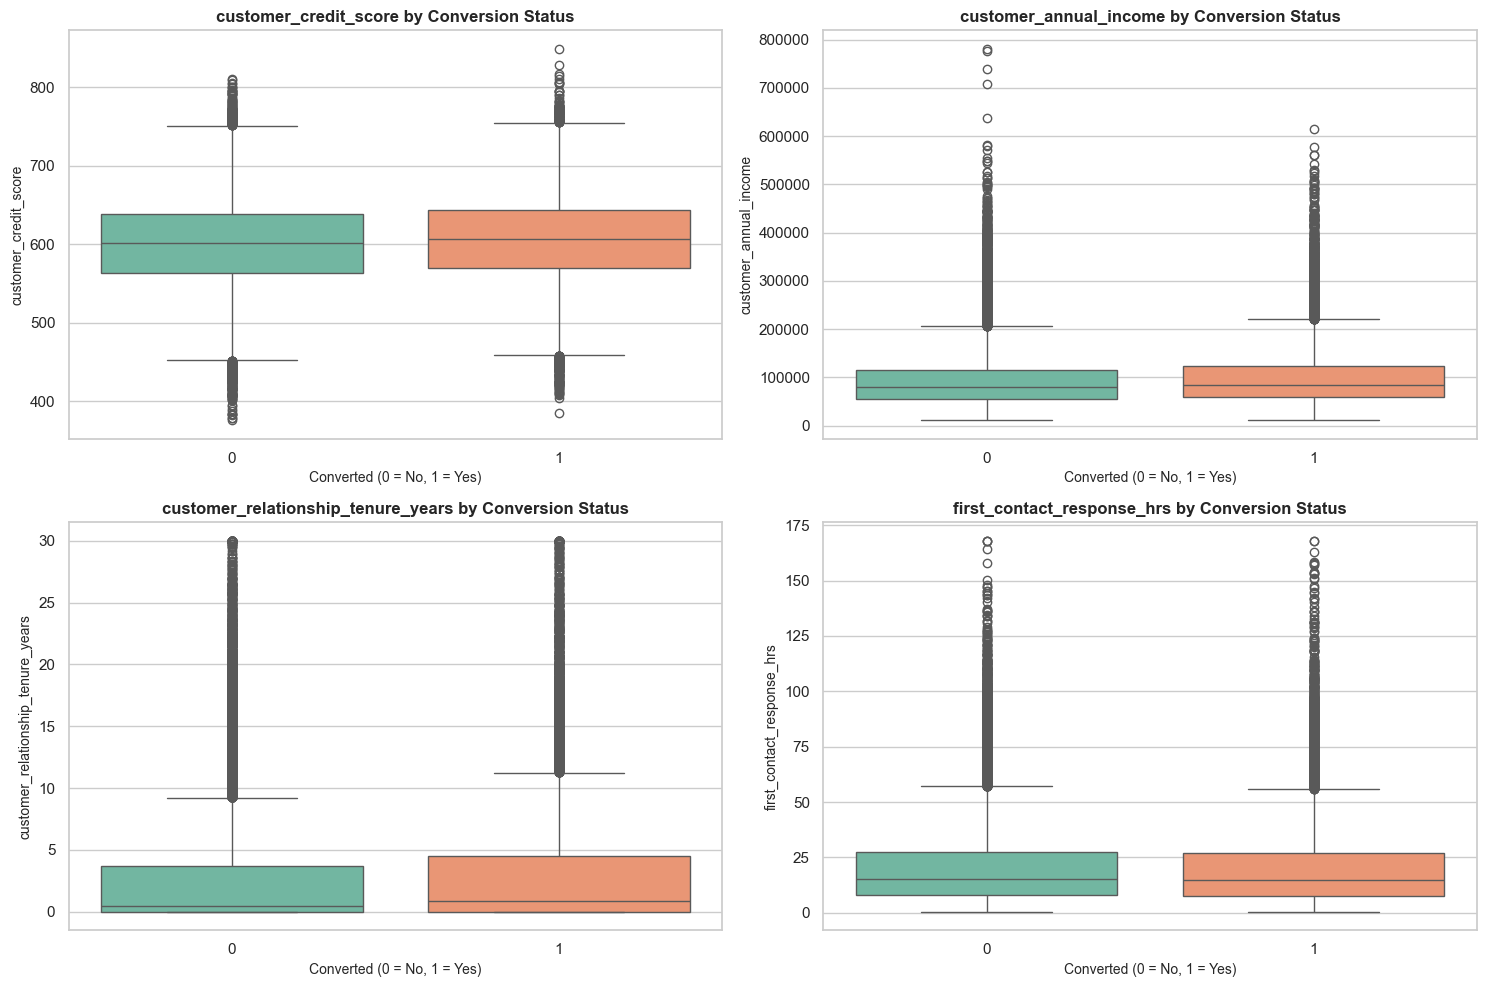

In [6]:
# Key Numeric Features vs Conversion
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features_to_plot = ['customer_credit_score', 'customer_annual_income', 
                     'customer_relationship_tenure_years', 'first_contact_response_hrs']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(x='converted', y=feature, hue='converted', data=df, palette='Set2', ax=ax, legend=False)
    ax.set_title(f'{feature} by Conversion Status', fontsize=12, fontweight='bold')
    ax.set_xlabel('Converted (0 = No, 1 = Yes)', fontsize=10)
    ax.set_ylabel(feature, fontsize=10)

plt.tight_layout()
plt.show()

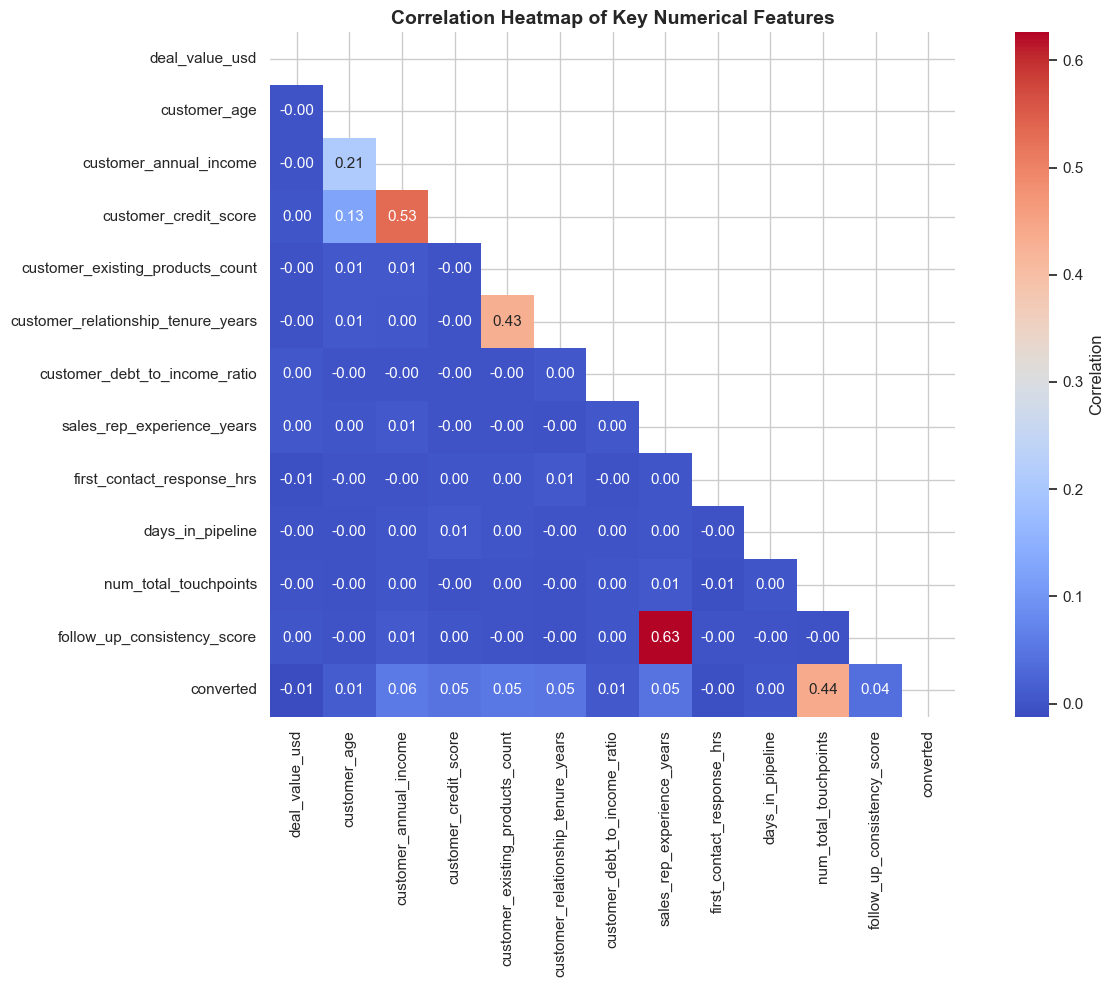

In [7]:
# Correlation Heatmap
numeric_cols = [
    'deal_value_usd', 'customer_age', 'customer_annual_income', 'customer_credit_score', 
    'customer_existing_products_count', 'customer_relationship_tenure_years', 
    'customer_debt_to_income_ratio', 'sales_rep_experience_years', 'first_contact_response_hrs',
    'days_in_pipeline', 'num_total_touchpoints', 'follow_up_consistency_score', 'converted'
]

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Key Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

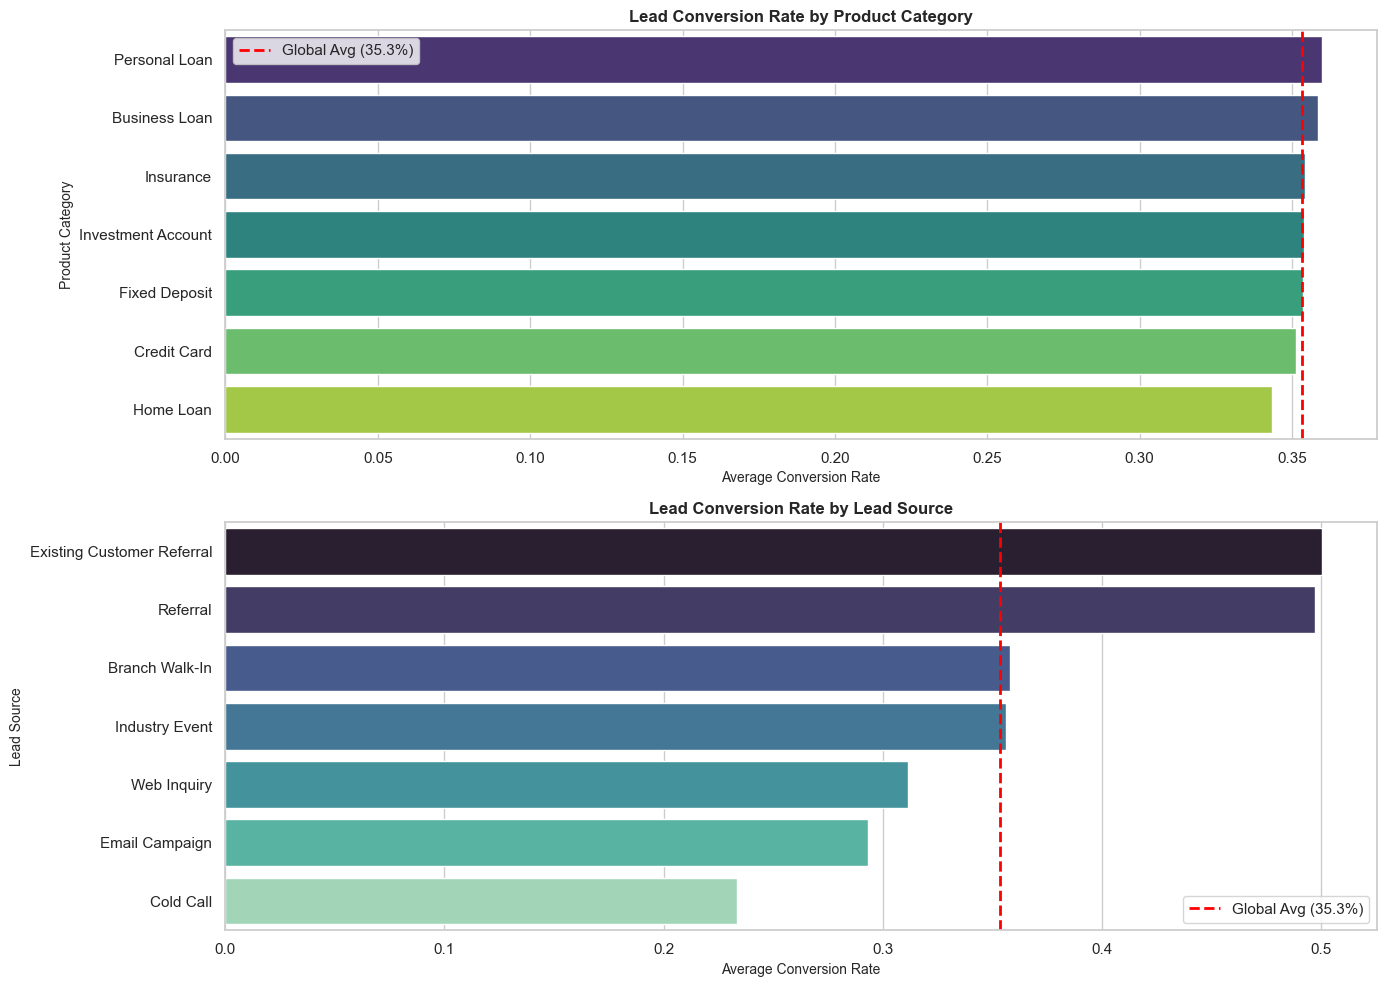

In [8]:
# Conversion by Product Category
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Product Category
product_conv = df.groupby('product_category')['converted'].agg(['mean', 'count']).reset_index().sort_values(by='mean', ascending=False)
sns.barplot(x='mean', y='product_category', hue='product_category', data=product_conv, palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Lead Conversion Rate by Product Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Conversion Rate', fontsize=10)
axes[0].set_ylabel('Product Category', fontsize=10)
axes[0].axvline(df['converted'].mean(), color='red', linestyle='--', linewidth=2, label=f'Global Avg ({df["converted"].mean()*100:.1f}%)')
axes[0].legend()

# Lead Source
source_conv = df.groupby('lead_source')['converted'].agg(['mean', 'count']).reset_index().sort_values(by='mean', ascending=False)
sns.barplot(x='mean', y='lead_source', hue='lead_source', data=source_conv, palette='mako', ax=axes[1], legend=False)
axes[1].set_title('Lead Conversion Rate by Lead Source', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Conversion Rate', fontsize=10)
axes[1].set_ylabel('Lead Source', fontsize=10)
axes[1].axvline(df['converted'].mean(), color='red', linestyle='--', linewidth=2, label=f'Global Avg ({df["converted"].mean()*100:.1f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step-3. Preprocessing & Feature Engineering

In [9]:
# Create a copy for processing
df_processed = df.sample(n=min(5000, len(df)), random_state=42).copy()
print(f"Using {len(df_processed):,} records for faster model training and notebook execution.")

# Feature Engineering
print("Engineering custom features...")
df_processed['income_to_deal_ratio'] = df_processed['customer_annual_income'] / (df_processed['deal_value_usd'] + 1)
df_processed['touchpoints_per_day'] = df_processed['num_total_touchpoints'] / (df_processed['days_in_pipeline'] + 1)
df_processed['credit_score_normalized'] = df_processed['customer_credit_score'] / 850  # Normalize by max credit score
df_processed['high_value_customer'] = (df_processed['customer_annual_income'] > df_processed['customer_annual_income'].median()).astype(int)

print(" Feature engineering complete!")
print(f"   New features created: income_to_deal_ratio, touchpoints_per_day, credit_score_normalized, high_value_customer")

Using 5,000 records for faster model training and notebook execution.
Engineering custom features...
 Feature engineering complete!
   New features created: income_to_deal_ratio, touchpoints_per_day, credit_score_normalized, high_value_customer


In [10]:
# Separate Target and Features
X = df_processed.drop(columns=['lead_id', 'sales_rep_id', 'converted'])
y = df_processed['converted']

# Identify feature types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"  Features Prepared:")
print(f"   Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"   Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"   Total features: {len(numerical_cols) + len(categorical_cols)}")
print(f"   Target variable distribution:\n{y.value_counts()}")

  Features Prepared:
   Numerical features (27): ['deal_value_usd', 'customer_age', 'customer_annual_income', 'customer_credit_score', 'customer_existing_products_count', 'customer_relationship_tenure_years', 'customer_debt_to_income_ratio', 'sales_rep_experience_years', 'sales_rep_monthly_quota_usd', 'sales_rep_ytd_quota_attainment_pct', 'first_contact_response_hrs', 'days_in_pipeline', 'num_total_touchpoints', 'num_calls_made', 'num_emails_sent', 'num_meetings_held', 'proposal_sent', 'needs_analysis_completed', 'competitor_present', 'discount_offered_pct', 'manager_escalated', 'customer_objection_raised', 'follow_up_consistency_score', 'income_to_deal_ratio', 'touchpoints_per_day', 'credit_score_normalized', 'high_value_customer']
   Categorical features (12): ['lead_source', 'product_category', 'product_sub_category', 'customer_type', 'customer_gender', 'customer_employment_type', 'customer_state', 'customer_city_tier', 'sales_rep_region', 'sales_rep_tier', 'last_stage_reached', 'se

In [11]:
# Train-Test Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"  Data Split Complete:")
print(f"   Train set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"   Features per sample: {X_train.shape[1]}")
print(f"\n   Train set conversion rate: {y_train.mean()*100:.2f}%")
print(f"   Test set conversion rate:  {y_test.mean()*100:.2f}%")

  Data Split Complete:
   Train set: 4,000 samples (80.0%)
   Test set:  1,000 samples (20.0%)
   Features per sample: 39

   Train set conversion rate: 34.60%
   Test set conversion rate:  34.60%


In [12]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_cols)
    ]
)

print("  Preprocessing pipeline built successfully!")

  Preprocessing pipeline built successfully!


## Step-4. Model Training & Comparison

In [13]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=25, max_depth=8, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=25,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

# Train all models
results = []
trained_pipelines = {}
predictions_dict = {}

print("  Training Models...\n")
for model_name, model in models.items():
    print(f"    Training {model_name}...")
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline
    
    # Predict
    y_pred_model = pipeline.predict(X_test)
    y_pred_proba_model = pipeline.predict_proba(X_test)[:, 1]
    predictions_dict[model_name] = {'pred': y_pred_model, 'proba': y_pred_proba_model}
    
    # Calculate metrics
    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred_model),
        'Precision': precision_score(y_test, y_pred_model),
        'Recall': recall_score(y_test, y_pred_model),
        'F1-Score': f1_score(y_test, y_pred_model),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_model)
    })
    print(f"    {model_name} completed")

# Results dataframe
df_results_numeric = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
df_results = df_results_numeric.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    df_results[col] = df_results[col].map(lambda x: f"{x:.4f}")

print("\n Model Performance Results:")
df_results

  Training Models...

    Training Logistic Regression...
    Logistic Regression completed
    Training Random Forest...
    Random Forest completed
    Training XGBoost...
    XGBoost completed

 Model Performance Results:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7410,0.6314,0.6040,0.6174,0.8057
1,XGBoost,0.7560,0.6835,0.5491,0.6090,0.8041
2,Random Forest,0.7410,0.6526,0.5376,0.5895,0.7922


## Step-5. Model Evaluation & Metrics Comparison

In [14]:
# Display results
print("\n Model Performance Results:\n")
print(df_results.to_string(index=False))
print("\n" + "="*80)


 Model Performance Results:

              Model Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression   0.7410    0.6314 0.6040   0.6174  0.8057
            XGBoost   0.7560    0.6835 0.5491   0.6090  0.8041
      Random Forest   0.7410    0.6526 0.5376   0.5895  0.7922



In [15]:
# Extract numeric values for comparison
df_results_numeric = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    df_results_numeric[col] = df_results_numeric[col].astype(float)

# Identify champion model
champion_name = df_results_numeric.loc[df_results_numeric['ROC-AUC'].astype(float).idxmax(), 'Model']
champion_roc_auc = df_results_numeric.loc[df_results_numeric['Model'] == champion_name, 'ROC-AUC'].values[0]

print(f"\n CHAMPION MODEL: {champion_name}")
print(f"   ROC-AUC Score: {champion_roc_auc:.4f}")
print(f"\nThis model will be used for further analysis and predictions.")


 CHAMPION MODEL: Logistic Regression
   ROC-AUC Score: 0.8057

This model will be used for further analysis and predictions.


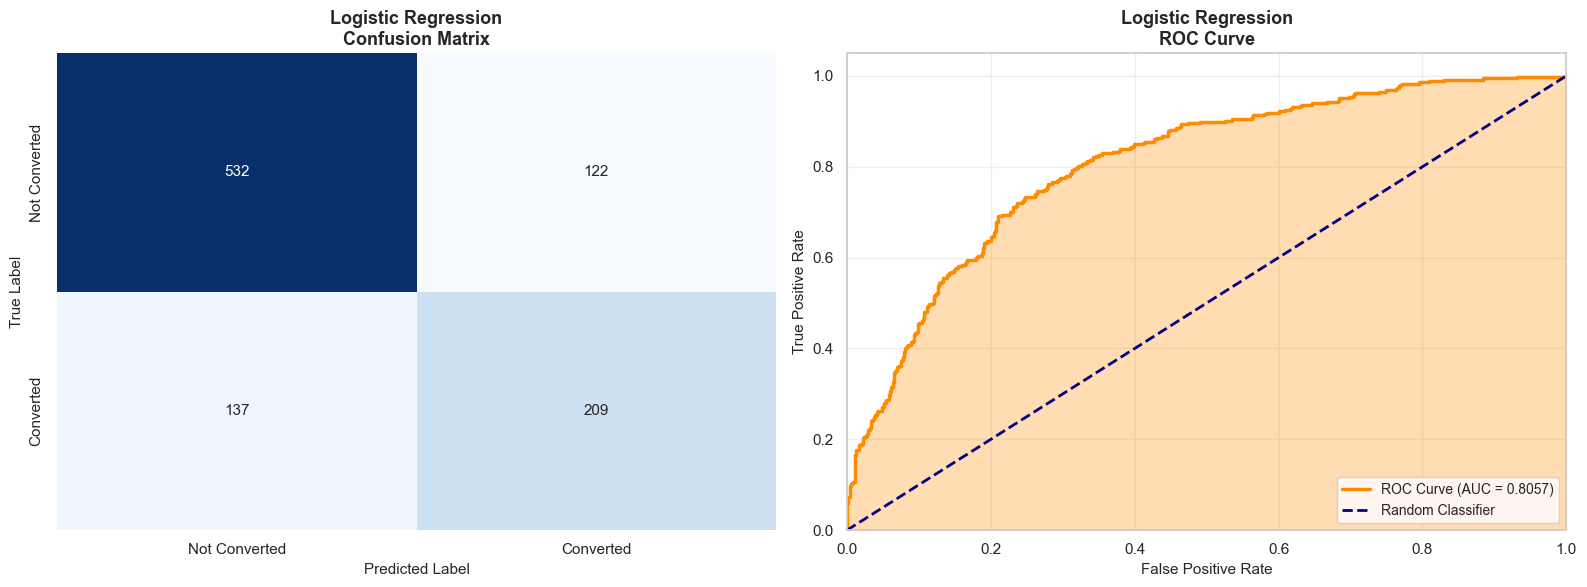

In [16]:
# Get champion predictions
champion_pipeline = trained_pipelines[champion_name]
y_pred = predictions_dict[champion_name]['pred']
y_pred_proba = predictions_dict[champion_name]['proba']

# Create evaluation plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0], 
            xticklabels=['Not Converted', 'Converted'], yticklabels=['Not Converted', 'Converted'])
axes[0].set_title(f'{champion_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2.5, 
             label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.3, color='darkorange')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title(f'{champion_name}\nROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Detailed Classification Report
print(f"\n DETAILED CLASSIFICATION REPORT - {champion_name}\n")
print(classification_report(y_test, y_pred, target_names=['Not Converted', 'Converted'], digits=4))


 DETAILED CLASSIFICATION REPORT - Logistic Regression

               precision    recall  f1-score   support

Not Converted     0.7952    0.8135    0.8042       654
    Converted     0.6314    0.6040    0.6174       346

     accuracy                         0.7410      1000
    macro avg     0.7133    0.7088    0.7108      1000
 weighted avg     0.7385    0.7410    0.7396      1000



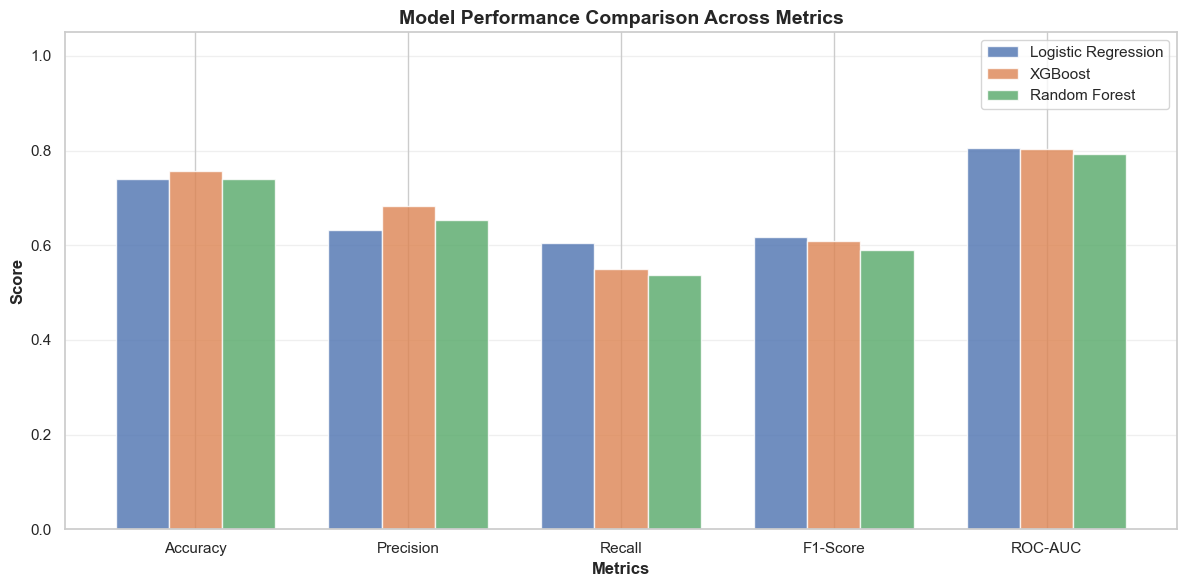

In [18]:
# Model Comparison Visualization
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

for i, model_name in enumerate(df_results_numeric['Model']):
    values = [float(df_results_numeric.loc[df_results_numeric['Model'] == model_name, m].values[0]) 
              for m in metrics]
    ax.bar(x + i*width, values, width, label=model_name, alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison Across Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step-6. Feature Importance & Business Insights

In [19]:
# Extract feature importances
print(" Extracting feature importances...")

# Get the best performing model (using Random Forest for interpretability)
rf_pipeline = trained_pipelines['Random Forest']
rf_model = rf_pipeline.named_steps['classifier']
preprocessor_obj = rf_pipeline.named_steps['preprocessor']

# Get feature names
cat_features_encoded = preprocessor_obj.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_features_encoded

# Get importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Create DataFrame
df_importance = pd.DataFrame({
    'Feature': [all_feature_names[i] for i in indices],
    'Importance': importances[indices]
})

print(" Feature importance extraction complete!")
print(f"\nTop 20 Most Important Features:")
print(df_importance.head(20).to_string(index=False))

 Extracting feature importances...
 Feature importance extraction complete!

Top 20 Most Important Features:
                           Feature  Importance
last_stage_reached_Contract Review    0.103073
              discount_offered_pct    0.088182
                   num_emails_sent    0.086100
             num_total_touchpoints    0.067452
                    num_calls_made    0.066409
                 num_meetings_held    0.040072
                     proposal_sent    0.031831
  last_stage_reached_Qualification    0.027216
            customer_annual_income    0.026238
    last_stage_reached_Negotiation    0.023312
             customer_credit_score    0.020144
        first_contact_response_hrs    0.018754
               touchpoints_per_day    0.018642
              income_to_deal_ratio    0.018280
           credit_score_normalized    0.017772
sales_rep_ytd_quota_attainment_pct    0.017464
       follow_up_consistency_score    0.017068
customer_relationship_tenure_years    0.01645

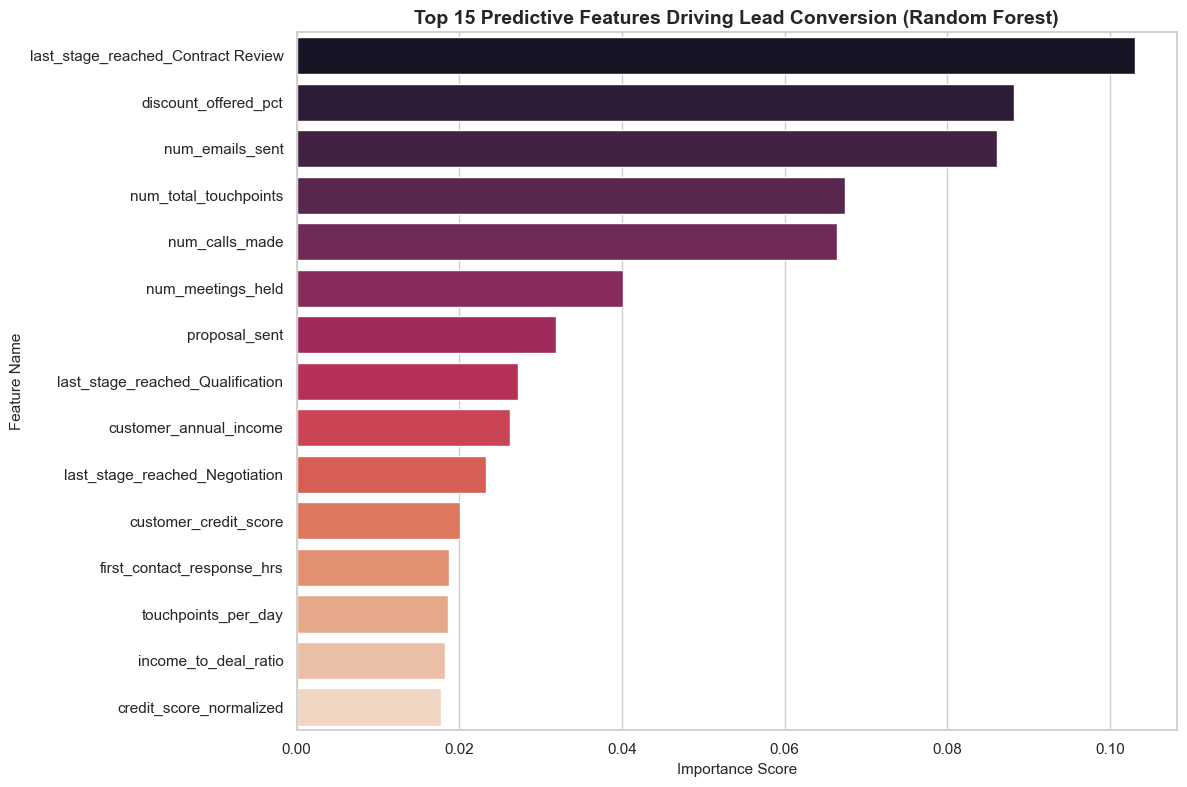

In [20]:
# Visualize top 15 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=df_importance.head(15), palette='rocket', legend=False)
plt.title('Top 15 Predictive Features Driving Lead Conversion (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Feature Name', fontsize=11)
plt.tight_layout()
plt.show()

## Step-7. Lead Scoring & Predictions

In [21]:
# Create lead scores for the same dataframe used for model training
# Here df_processed has 5,000 records, so we must add 5,000 predictions to df_processed only
scored_df = df_processed.copy()

all_scores = champion_pipeline.predict_proba(X)[:, 1]
all_predictions = champion_pipeline.predict(X)

scored_df['lead_score'] = all_scores
scored_df['predicted_conversion'] = all_predictions

# Categorize leads
scored_df['lead_category'] = pd.cut(
    scored_df['lead_score'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Priority', 'Medium Priority', 'High Priority'],
    include_lowest=True
)

print(" Lead Scoring Complete!\n")
print("Lead Score Distribution:")
print(f"   Mean: {scored_df['lead_score'].mean():.4f}")
print(f"   Median: {scored_df['lead_score'].median():.4f}")
print(f"   Min: {scored_df['lead_score'].min():.4f}")
print(f"   Max: {scored_df['lead_score'].max():.4f}")
print("\nLead Priority Distribution:")
print(scored_df['lead_category'].value_counts().sort_index())

 Lead Scoring Complete!

Lead Score Distribution:
   Mean: 0.3476
   Median: 0.3079
   Min: 0.0060
   Max: 0.9451

Lead Priority Distribution:
lead_category
Low Priority       2461
Medium Priority    1987
High Priority       552
Name: count, dtype: int64


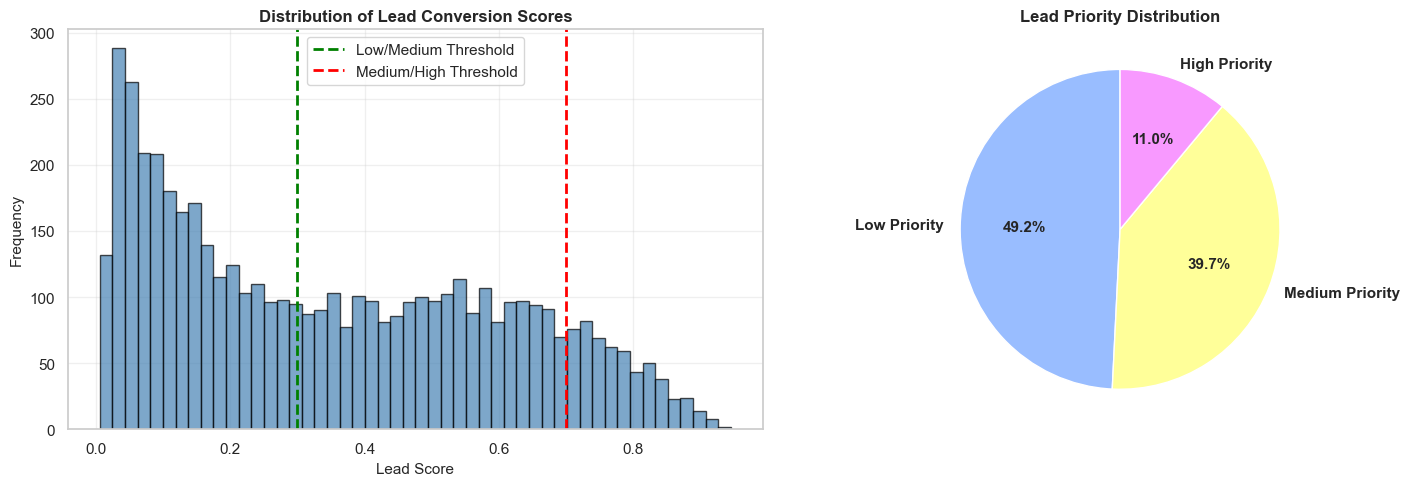

In [22]:
# Visualize lead scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Lead score distribution
axes[0].hist(scored_df['lead_score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0.3, color='green', linestyle='--', linewidth=2, label='Low/Medium Threshold')
axes[0].axvline(0.7, color='red', linestyle='--', linewidth=2, label='Medium/High Threshold')
axes[0].set_title('Distribution of Lead Conversion Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lead Score', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Lead priority distribution
priority_counts = scored_df['lead_category'].value_counts()
colors_priority = ["#99bdff", '#ffff99', "#f899ff"]
axes[1].pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%', 
            colors=colors_priority, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Lead Priority Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# High priority leads sample
high_priority = scored_df[scored_df['lead_category'] == 'High Priority'].sort_values('lead_score', ascending=False)

print(f"\n HIGH PRIORITY LEADS (Top 10)\n")
print(f"Total High Priority Leads: {len(high_priority):,}")
print(f"\nTop 10 Leads to Focus On:")
display_cols = ['lead_id', 'customer_age', 'customer_annual_income', 'product_category', 'lead_source', 'lead_score', 'predicted_conversion']
print(high_priority[display_cols].head(10).to_string(index=False))


 HIGH PRIORITY LEADS (Top 10)

Total High Priority Leads: 552

Top 10 Leads to Focus On:
   lead_id  customer_age  customer_annual_income   product_category                lead_source  lead_score  predicted_conversion
LEAD003343            41                   74587          Insurance             Branch Walk-In    0.945103                     1
LEAD052367            37                   55934      Fixed Deposit Existing Customer Referral    0.926491                     1
LEAD004347            39                   65414 Investment Account             Email Campaign    0.924844                     1
LEAD007481            78                  403027          Insurance             Email Campaign    0.923716                     1
LEAD015599            62                   83503 Investment Account Existing Customer Referral    0.921576                     1
LEAD038997            25                   40965          Insurance Existing Customer Referral    0.920279                     1
LEAD069

## Step-8. Notebook Prediction Engine

In [24]:
# Test prediction directly inside the notebook using one sample lead
sample_new_lead = X_test.iloc[[0]].copy()

sample_prediction = champion_pipeline.predict(sample_new_lead)[0]
sample_probability = champion_pipeline.predict_proba(sample_new_lead)[0][1]

print(" New Lead Prediction Completed")
print(f"Prediction: {'Likely to Convert' if sample_prediction == 1 else 'Not Likely to Convert'}")
print(f"Conversion Probability / Lead Score: {sample_probability:.4f}")

if sample_probability >= 0.70:
    priority = 'High Priority'
elif sample_probability >= 0.30:
    priority = 'Medium Priority'
else:
    priority = 'Low Priority'

print(f"Lead Priority: {priority}")
sample_new_lead

 New Lead Prediction Completed
Prediction: Not Likely to Convert
Conversion Probability / Lead Score: 0.1676
Lead Priority: Low Priority


,lead_source,product_category,product_sub_category,deal_value_usd,customer_type,customer_age,customer_gender,customer_employment_type,customer_annual_income,customer_credit_score,...,competitor_present,discount_offered_pct,manager_escalated,customer_objection_raised,follow_up_consistency_score,sentiment_last_interaction,income_to_deal_ratio,touchpoints_per_day,credit_score_normalized,high_value_customer
52214,Email Campaign,Fixed Deposit,60-Month,28697,New,74,Female,Salaried,86741,665,...,0,0.0,0,1,68,Neutral,3.022545,0.9,0.782353,1


## Step-8. Business Recommendations & Strategy

In [25]:
print("\n" + "="*80)
print(" STRATEGIC BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*80)

print("\n1️  KEY FACTORS DRIVING CONVERSION:")
top_features = df_importance.head(5)
for idx, row in top_features.iterrows():
    print(f"   • {row['Feature']}: {row['Importance']*100:.2f}% importance")

print("\n2️  CONVERSION METRICS BY CATEGORY:")
cat_analysis = df.groupby('product_category')['converted'].agg(['mean', 'count']).round(3)
for cat in cat_analysis.index:
    conv_rate = cat_analysis.loc[cat, 'mean'] * 100
    count = int(cat_analysis.loc[cat, 'count'])
    print(f"   • {cat}: {conv_rate:.1f}% conversion ({count:,} leads)")

print("\n3️  LEAD SOURCE EFFECTIVENESS:")
source_analysis = df.groupby('lead_source')['converted'].agg(['mean', 'count']).sort_values('mean', ascending=False)
for source in source_analysis.index:
    conv_rate = source_analysis.loc[source, 'mean'] * 100
    count = int(source_analysis.loc[source, 'count'])
    print(f"   • {source}: {conv_rate:.1f}% conversion ({count:,} leads)")

print("\n4️  PRIORITIZATION STRATEGY:")
high_count = len(scored_df[scored_df['lead_category'] == 'High Priority'])
medium_count = len(scored_df[scored_df['lead_category'] == 'Medium Priority'])
low_count = len(scored_df[scored_df['lead_category'] == 'Low Priority'])

print(f"   • High Priority Leads (Score > 0.70): {high_count:,} ({high_count/len(scored_df)*100:.1f}%)")
print(f"   • Medium Priority Leads (0.30-0.70): {medium_count:,} ({medium_count/len(scored_df)*100:.1f}%)")
print(f"   • Low Priority Leads (Score < 0.30): {low_count:,} ({low_count/len(scored_df)*100:.1f}%)")

print("\n5️  MODEL PERFORMANCE:")
print(f"   • Champion Model: {champion_name}")
print(f"   • ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"   • Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"   • Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   • Recall: {recall_score(y_test, y_pred):.4f}")

print("\n6️  ACTIONABLE RECOMMENDATIONS:")
print("   ✓ Focus sales efforts on HIGH PRIORITY leads (>70% conversion probability)")
print("   ✓ Optimize follow-up consistency - it's a top conversion driver")
print("   ✓ Reduce first contact response time - faster response = higher conversion")
print("   ✓ Prioritize high-income customers with good credit scores")
print("   ✓ Allocate more resources to top-performing lead sources")
print("   ✓ Use this model for real-time lead scoring to maximize ROI")

print("\n" + "="*80)


 STRATEGIC BUSINESS INSIGHTS & RECOMMENDATIONS

1️  KEY FACTORS DRIVING CONVERSION:
   • last_stage_reached_Contract Review: 10.31% importance
   • discount_offered_pct: 8.82% importance
   • num_emails_sent: 8.61% importance
   • num_total_touchpoints: 6.75% importance
   • num_calls_made: 6.64% importance

2️  CONVERSION METRICS BY CATEGORY:
   • Business Loan: 35.9% conversion (7,418 leads)
   • Credit Card: 35.1% conversion (12,601 leads)
   • Fixed Deposit: 35.4% conversion (3,656 leads)
   • Home Loan: 34.3% conversion (13,407 leads)
   • Insurance: 35.4% conversion (9,701 leads)
   • Investment Account: 35.4% conversion (11,170 leads)
   • Personal Loan: 36.0% conversion (16,433 leads)

3️  LEAD SOURCE EFFECTIVENESS:
   • Existing Customer Referral: 50.1% conversion (8,873 leads)
   • Referral: 49.7% conversion (8,935 leads)
   • Branch Walk-In: 35.8% conversion (13,380 leads)
   • Industry Event: 35.6% conversion (5,187 leads)
   • Web Inquiry: 31.2% conversion (14,962 leads)


## Step-9. Model Persistence & Export

In [26]:
# Save the champion model
import joblib

model_path = 'champion_model.pkl'
joblib.dump(champion_pipeline, model_path)
print(f" Champion model saved: {model_path}")

# Save results
results_path = 'model_results.csv'
df_results.to_csv(results_path, index=False)
print(f" Model results saved: {results_path}")

# Save feature importance
importance_path = 'feature_importance.csv'
df_importance.to_csv(importance_path, index=False)
print(f" Feature importance saved: {importance_path}")

# Save lead scores
scores_path = 'lead_scores.csv'
scored_df[['lead_id', 'lead_score', 'predicted_conversion', 'lead_category']].to_csv(scores_path, index=False)
print(f" Lead scores saved: {scores_path}")

 Champion model saved: champion_model.pkl
 Model results saved: model_results.csv
 Feature importance saved: feature_importance.csv
 Lead scores saved: lead_scores.csv


In [27]:
print("\n" + "="*80)
print(" PROJECT COMPLETE!")
print("="*80)
print("\n Output Files Generated:")
print(f"   1. champion_model.pkl - Trained ML model for predictions")
print(f"   2. model_results.csv - Performance metrics of all models")
print(f"   3. feature_importance.csv - Feature importance rankings")
print(f"   4. lead_scores.csv - All leads with conversion scores")
print("\n Next Steps:")
print("   • Use lead_scores.csv to prioritize sales activities")
print("   • Deploy champion_model.pkl for real-time lead scoring")
print("   • Review feature_importance.csv for business insights")
print("   • Monitor model performance over time and retrain periodically")
print("\n" + "="*80)


 PROJECT COMPLETE!

 Output Files Generated:
   1. champion_model.pkl - Trained ML model for predictions
   2. model_results.csv - Performance metrics of all models
   3. feature_importance.csv - Feature importance rankings
   4. lead_scores.csv - All leads with conversion scores

 Next Steps:
   • Use lead_scores.csv to prioritize sales activities
   • Deploy champion_model.pkl for real-time lead scoring
   • Review feature_importance.csv for business insights
   • Monitor model performance over time and retrain periodically

